# Movie Review Emotion Classification using TF-IDF, TruncatedSVD and MLP



- **TF-IDF (Term Frequency–Inverse Document Frequency):** Converts movie review text into numerical features while giving greater importance to informative words and phrases.
- **TruncatedSVD (Latent Semantic Analysis):** Reduces the high-dimensional and sparse TF-IDF feature space into a smaller set of latent semantic components while preserving important patterns in the text.
- **Multi-Layer Perceptron (MLP):** Uses the reduced numerical features to learn patterns and classify movie reviews into emotion categories.

The notebook evaluates a **Baseline MLP**, investigates **Random Oversampling** to address class imbalance, and performs **hyperparameter tuning using GridSearchCV**. The models are evaluated using **Accuracy, Macro F1-score, classification reports, and a confusion matrix**.

In [34]:
!git clone https://github.com/it25102877/IT2011-AIML-Project.git
%cd IT2011-AIML-Project

Cloning into 'IT2011-AIML-Project'...
remote: Enumerating objects: 567, done.
remote: Counting objects: 100% (161/161), done.
remote: Compressing objects: 100% (87/87), done.
remote: Total 567 (delta 119), reused 75 (delta 74), pack-reused 406 (from 1)
Receiving objects: 100% (567/567), 27.88 MiB | 20.67 MiB/s, done.
Resolving deltas: 100% (264/264), done.
/content/IT2011-AIML-Project/IT2011-AIML-Project


In [41]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [43]:
!ls -lh "/content/drive/MyDrive/AIML Project"

total 25M
-rw------- 1 root root 25M Oct  3 02:59 Movies_Reviews_modified_version1.csv.xlsx


In [45]:
import pandas as pd

FILE_PATH = "/content/drive/MyDrive/AIML Project/Movies_Reviews_modified_version1.csv.xlsx"

df = pd.read_excel(FILE_PATH)

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Dataset Shape: (46173, 8)

Columns:
['Unnamed: 0', 'Ratings', 'Reviews', 'movie_name', 'Resenhas', 'genres', 'Description', 'emotion']


,Unnamed: 0,Ratings,Reviews,movie_name,Resenhas,genres,Description,emotion
0,0,3,"It had some laughs, but overall the motivation...",Waiting to Exhale,"Riu algumas risadas, mas no geral a motivaÃ§Ã£...","['Comedy', 'Drama', 'Romance']","Based on Terry McMillan's novel, this film fol...",anticipation
1,1,4,"WAITING TO EXHALE Waiting, and waiting, and wa...",Waiting to Exhale,"ESPERANDO PARA EXALAR Esperando, e esperando, ...","['Comedy', 'Drama', 'Romance']","Based on Terry McMillan's novel, this film fol...",anticipation
2,2,4,"Angela Basset was good as expected, but Whitne...",Waiting to Exhale,"Angela Basset foi boa como o esperado, mas Whi...","['Comedy', 'Drama', 'Romance']","Based on Terry McMillan's novel, this film fol...",anticipation
3,3,5,"The movie is okay, mediocre might even be the ...",Waiting to Exhale,"O filme Ã© bom, medÃ­ocre pode atÃ© ser a pala...","['Comedy', 'Drama', 'Romance']","Based on Terry McMillan's novel, this film fol...",anticipation
4,4,5,I got an opportunity to see Waiting To Exhale ...,Waiting to Exhale,Tive a oportunidade de ver Waiting To Exhale p...,"['Comedy', 'Drama', 'Romance']","Based on Terry McMillan's novel, this film fol...",anticipation


## Prepare Data for Model Training

In [46]:
from sklearn.model_selection import train_test_split

# SVD features
X = svd_matrix

# Target emotion
y = sample_df["emotion"].values

# Split into training and testing data
X_train_svd, X_test_svd, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Features:", X_train_svd.shape)
print("Testing Features:", X_test_svd.shape)

print("Training Labels:", y_train.shape)
print("Testing Labels:", y_test.shape)

Training Features: (12000, 50)
Testing Features: (3000, 50)
Training Labels: (12000,)
Testing Labels: (3000,)


# 2. Label Encoding

In [47]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Emotion Classes:")
for i, emotion in enumerate(label_encoder.classes_):
    print(f"{emotion} -> {i}")

Emotion Classes:
anger -> 0
anticipation -> 1
disgust -> 2
fear -> 3
joy -> 4
optimism -> 5
sadness -> 6
surprise -> 7


# 3. Baseline MLP Classifier

In [48]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

baseline_mlp = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation="relu",
    solver="adam",
    alpha=0.0001,
    learning_rate_init=0.001,
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=42
)

baseline_mlp.fit(X_train_svd, y_train_encoded)

y_pred_baseline = baseline_mlp.predict(X_test_svd)

baseline_accuracy = accuracy_score(
    y_test_encoded,
    y_pred_baseline
)

baseline_macro_f1 = f1_score(
    y_test_encoded,
    y_pred_baseline,
    average="macro"
)

print(f"Baseline Accuracy: {baseline_accuracy:.4f}")
print(f"Baseline Macro F1: {baseline_macro_f1:.4f}")
print("Training Iterations:", baseline_mlp.n_iter_)

Baseline Accuracy: 0.3813
Baseline Macro F1: 0.0946
Training Iterations: 18


#4. Baseline MLP Evaluation

In [49]:
print(
    classification_report(
        y_test_encoded,
        y_pred_baseline,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

              precision    recall  f1-score   support

       anger       0.43      0.06      0.11       237
anticipation       0.00      0.00      0.00       481
     disgust       0.00      0.00      0.00       110
        fear       0.26      0.04      0.07       231
         joy       0.26      0.01      0.02       505
    optimism       0.20      0.00      0.01       310
     sadness       0.38      0.99      0.55      1122
    surprise       0.00      0.00      0.00         4

    accuracy                           0.38      3000
   macro avg       0.19      0.14      0.09      3000
weighted avg       0.26      0.38      0.22      3000



# 5.Class Imbalance Handling



##5.1  Random Oversampling

In [50]:
from imblearn.over_sampling import RandomOverSampler
from collections import Counter

ros = RandomOverSampler(random_state=42)

X_train_resampled, y_train_resampled = ros.fit_resample(
    X_train_svd,
    y_train_encoded
)

print("Before Oversampling:")
print(Counter(y_train_encoded))

print("\nAfter Oversampling:")
print(Counter(y_train_resampled))

print("\nOriginal Training Shape:", X_train_svd.shape)
print("Resampled Training Shape:", X_train_resampled.shape)
print("Test Shape:", X_test_svd.shape)

Before Oversampling:
Counter({np.int64(6): 4490, np.int64(4): 2018, np.int64(1): 1924, np.int64(5): 1240, np.int64(0): 949, np.int64(3): 926, np.int64(2): 438, np.int64(7): 15})

After Oversampling:
Counter({np.int64(3): 4490, np.int64(6): 4490, np.int64(0): 4490, np.int64(4): 4490, np.int64(1): 4490, np.int64(5): 4490, np.int64(2): 4490, np.int64(7): 4490})

Original Training Shape: (12000, 50)
Resampled Training Shape: (35920, 50)
Test Shape: (3000, 50)


#6. MLP Training with Oversampled Data

In [51]:
oversampled_mlp = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation="relu",
    solver="adam",
    alpha=0.0001,
    learning_rate_init=0.001,
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=42
)

oversampled_mlp.fit(
    X_train_resampled,
    y_train_resampled
)

y_pred_oversampled = oversampled_mlp.predict(X_test_svd)

oversampled_accuracy = accuracy_score(
    y_test_encoded,
    y_pred_oversampled
)

oversampled_macro_f1 = f1_score(
    y_test_encoded,
    y_pred_oversampled,
    average="macro"
)

print(f"Oversampled Accuracy: {oversampled_accuracy:.4f}")
print(f"Oversampled Macro F1: {oversampled_macro_f1:.4f}")
print("Training Iterations:", oversampled_mlp.n_iter_)

Oversampled Accuracy: 0.2467
Oversampled Macro F1: 0.2319
Training Iterations: 196


#7. Oversampled MLP Evaluation

In [52]:
print(
    classification_report(
        y_test_encoded,
        y_pred_oversampled,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

              precision    recall  f1-score   support

       anger       0.21      0.35      0.26       237
anticipation       0.21      0.19      0.20       481
     disgust       0.15      0.40      0.21       110
        fear       0.18      0.35      0.24       231
         joy       0.27      0.25      0.26       505
    optimism       0.18      0.33      0.23       310
     sadness       0.56      0.19      0.28      1122
    surprise       0.12      0.25      0.17         4

    accuracy                           0.25      3000
   macro avg       0.24      0.29      0.23      3000
weighted avg       0.34      0.25      0.25      3000



#8. MLP Hyperparameter Tuning

In [53]:
from sklearn.model_selection import GridSearchCV

mlp_for_tuning = MLPClassifier(
    activation="relu",
    solver="adam",
    max_iter=200,
    early_stopping=True,
    n_iter_no_change=10,
    random_state=42
)

param_grid = {
    "hidden_layer_sizes": [
        (100,),
        (128, 64)
    ],
    "alpha": [
        0.0001,
        0.001
    ],
    "learning_rate_init": [
        0.001,
        0.0005
    ]
}

print("Number of configurations: 8")
print("5-fold CV total fits: 40")

Number of configurations: 8
5-fold CV total fits: 40


#9. GridSearchCV

In [54]:
grid_search = GridSearchCV(
    estimator=mlp_for_tuning,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    verbose=0
)

grid_search.fit(
    X_train_svd,
    y_train_encoded
)

print("Best Parameters:")
print(grid_search.best_params_)

print(
    f"Best CV Macro F1: "
    f"{grid_search.best_score_:.4f}"
)

Best Parameters:
{'alpha': 0.0001, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.001}
Best CV Macro F1: 0.1195


# 10. Final Tuned MLP Evaluation

In [55]:
best_mlp = grid_search.best_estimator_

y_pred_tuned = best_mlp.predict(X_test_svd)

tuned_accuracy = accuracy_score(
    y_test_encoded,
    y_pred_tuned
)

tuned_macro_f1 = f1_score(
    y_test_encoded,
    y_pred_tuned,
    average="macro"
)

print("Best Parameters:")
print(grid_search.best_params_)

print(f"\nTuned Accuracy: {tuned_accuracy:.4f}")
print(f"Tuned Macro F1: {tuned_macro_f1:.4f}")

print("\nClassification Report:")

print(
    classification_report(
        y_test_encoded,
        y_pred_tuned,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

Best Parameters:
{'alpha': 0.0001, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.001}

Tuned Accuracy: 0.3813
Tuned Macro F1: 0.1046

Classification Report:
              precision    recall  f1-score   support

       anger       0.39      0.08      0.14       237
anticipation       0.00      0.00      0.00       481
     disgust       0.00      0.00      0.00       110
        fear       0.28      0.08      0.12       231
         joy       0.24      0.01      0.02       505
    optimism       0.00      0.00      0.00       310
     sadness       0.39      0.98      0.55      1122
    surprise       0.00      0.00      0.00         4

    accuracy                           0.38      3000
   macro avg       0.16      0.14      0.10      3000
weighted avg       0.24      0.38      0.23      3000



##11. Final Tuned MLP Confusion Matrix

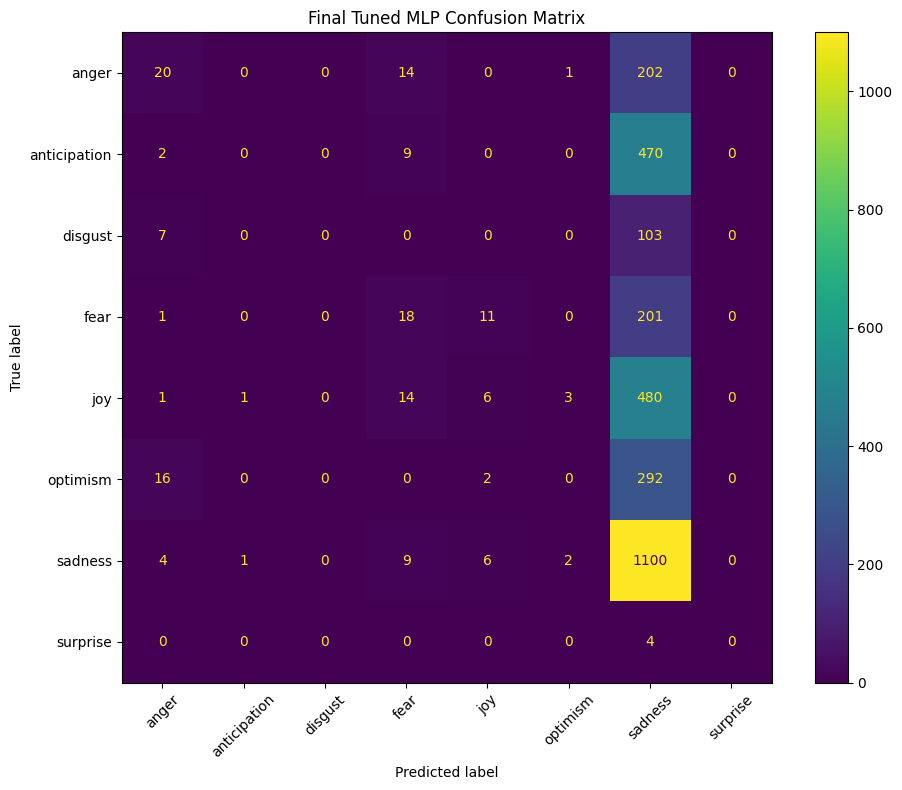

In [56]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(10, 8))

ConfusionMatrixDisplay.from_predictions(
    y_test_encoded,
    y_pred_tuned,
    display_labels=label_encoder.classes_,
    xticks_rotation=45,
    ax=ax
)

plt.title("Final Tuned MLP Confusion Matrix")
plt.tight_layout()
plt.show()

#12. MLP Model Comparison

In [57]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": [
        "Baseline MLP",
        "Oversampled MLP",
        "Tuned MLP"
    ],

    "Accuracy": [
        baseline_accuracy,
        oversampled_accuracy,
        tuned_accuracy
    ],

    "Macro F1": [
        baseline_macro_f1,
        oversampled_macro_f1,
        tuned_macro_f1
    ]
})

comparison_df


,Model,Accuracy,Macro F1
0,Baseline MLP,0.381333,0.094580
1,Oversampled MLP,0.246667,0.231882
2,Tuned MLP,0.381333,0.104645


#13.MLP Performance Comparison

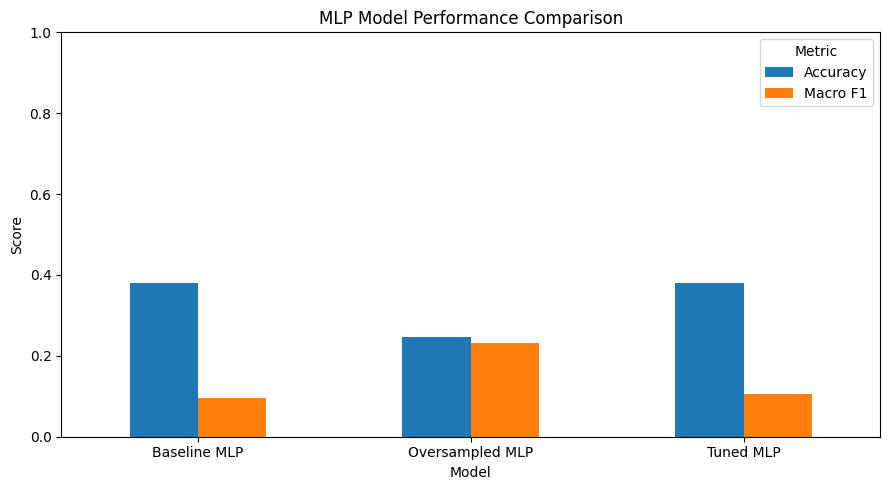

In [58]:
comparison_df.set_index("Model")[["Accuracy", "Macro F1"]].plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("MLP Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

##14. Best Model Selection

In [59]:
best_row = comparison_df.loc[
    comparison_df["Macro F1"].idxmax()
]

print("Best Model:", best_row["Model"])
print(f"Accuracy: {best_row['Accuracy']:.4f}")
print(f"Macro F1: {best_row['Macro F1']:.4f}")

Best Model: Oversampled MLP
Accuracy: 0.2467
Macro F1: 0.2319


## Conclusion and Limitations

This implementation used TF-IDF and TruncatedSVD features for emotion classification using a Multi-Layer Perceptron (MLP).

Three MLP configurations were evaluated: a Baseline MLP, an MLP trained with Random Oversampling, and a Tuned MLP selected using GridSearchCV.

Accuracy and Macro F1-score were used for model evaluation. Macro F1-score is particularly important because the emotion classes are imbalanced and it gives equal importance to each class.

### Limitations

- The emotion classes are highly imbalanced.
- Some minority emotion classes have very few samples.
- Emotion classes may contain overlapping semantic patterns.
- Dimensionality reduction may remove some useful information.
- Further improvements could explore alternative feature representations, imbalance-handling methods, SVD dimensions, and MLP architectures.